# Dependencias

In [ ]:
# Liberías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")
import warnings
warnings.filterwarnings('ignore')

# Modelos y métricas
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Pruebas estadísticas
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf                # autocorrelación
from statsmodels.tsa.stattools import adfuller                              # estacionariedad
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch           # heterocedasticidad residuos
from scipy.stats import shapiro, anderson, jarque_bera                      # normalidad residuos

# Información

## Autocovariance
The autocovariance function of a time series $\{X_t\}$ is defined as the second moment product
\begin{equation*}
    \gamma(t,s) = Cov(X_t, X_s) = E[(X_t - \mu_t)(X_t - \mu_s)]
\end{equation*}

The autocovariance measures the **linear dependence** between two points on the same series observed at different times $t,s$. 

## Autocorrelation
The autocorrelation function (ACF) is defined as
\begin{equation*}
    \rho(t,s) = \frac{\gamma (t,s)}{\sqrt{\gamma(t,t) \gamma(s,s)}}
\end{equation*}
This value is bounded in $-1 \le \rho(t,s) \le 1$

<span style="color: red;">Saliendo un poco de lo formal, algunos modelos matemáticos obligan imponer ciertas restricciones a la serie temporal. Esto se debe a que facilita la estimación de los parámetros y, principalmente, que la información del pasado permita predecir el futuro. Para lograr esto, se presenta el concepto de estacionariedad.  </span>

## Stationary Time Series

A time series $\{X_t\}$ is said to be stationary if
\begin{equation*}
    (X_{t_1},X_{t_2},\ldots ,X_{t_k}) \overset d = (X_{t_1+h},X_{t_2+h},\ldots ,X_{t_k+h})\ ,
\end{equation*}

for all integers $t_1,t_2,\ldots ,t_k,h$ and all positive integers $k$. This means that the statistical properties of the series do not change over time. In practice, this often implies that the mean, variance, and autocovariance of the series are constant over time.

This is a very strong condition that is hard to verify. A relaxed version is often assumed. 

## Weakly Stationary Time Series
A time series $\{X_t\}$ is said to be weakly stationary if
\begin{align*}
    &1.\ E[X_t] = E[X_{t+h}] = \mu \\
    &2.\ Cov(X_t, X_{t+h}) = Cov(X_{h},X_0) = \gamma(h) \,.
\end{align*}

In other words, the mean value and the acf are constant and doesn't depend on $t$.
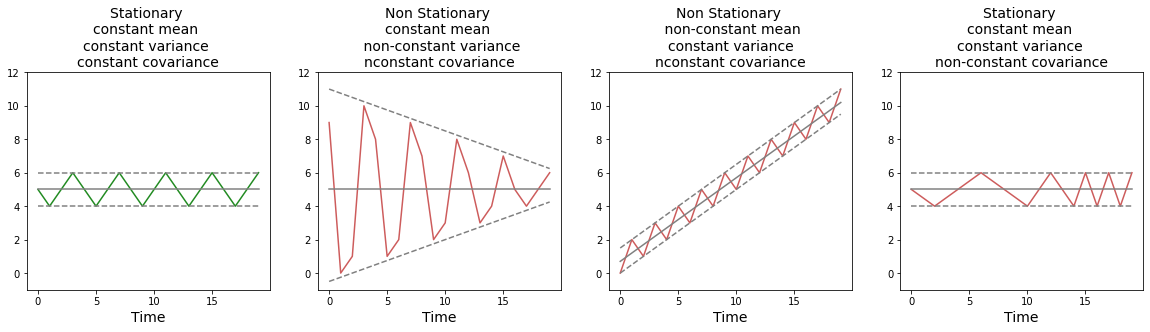  

## White noise
Given the process $\{\varepsilon_t\}$ with the following considerations:
* $E[\varepsilon_t] = 0$
* $Var(\varepsilon_t) = E[\varepsilon_t^2] = \sigma^2$
* $E[\varepsilon_t \varepsilon_s] = 0\, , \quad t \ne s$
* $\varepsilon_t \perp \varepsilon_s\,, \quad t \ne s$
* $\varepsilon_t \sim \mathcal N(0, \sigma^2)$


If the 3 first conditions are meet, then $\varepsilon_t$ is a white noise process; if the 4th is also fulfilled, it's namely as independent white noise process; if all the cathegories are achieved, then it's called gaussian noise process.


## Autoregression (AR) Model

Autoregressive models (AR models) are a concept in time series analysis and forecasting that captures the relationship between an observation and several lagged observations i.e previous time steps. Its idea is that the current value of a time series data can be expressed as a linear combination of its past values with some gaussian noise.

\begin{equation*}
    X_t = \phi_0 + \phi_1 X_{t-1} + \phi_2 X_{t-2} + \cdots + \phi_p X_{t-p} + \varepsilon_t\ ; \quad \varepsilon_t\overset{i.i.d}\sim \mathcal N(0,\sigma^2)
\end{equation*}

Where $\phi_0$ is called "drift" term. This parameter only appears when $X_t$ has non-zero mean, namely $\mu$. Formally $\phi_0 = \mu(1-\phi_1 - \cdots - \phi_p)$

<span style="color: red;"> #TODO: </span>
Encuentre la media, varianza y autocovarianza del modelo AR(1) dado por $X_t = \phi_1 X_{t-1} + \varepsilon_t$. 

Pista: Saque esperanza a ambos lados y aproveche las condiciones de estacionariedad débil y las propiedades de $\varepsilon_t$. Puede hacer lo mismo para la varianza y autocovarianza.

Sus respuestas deben ser
\begin{align*}
    &E[X_t] = 0 \\
    &Var[X_t] = \frac{\sigma^2} {1 - \phi_1^2} \\
    &Cov[X_t,X_s] = \frac{\sigma^2}{1-\phi_1^2} \phi_1^h, \quad h\ge 0
\end{align*}

<span style="color: red;"> #TODO: </span> Por qué tiene que imponerse la restricción $|\phi_1| < 1$? Reflexione</span>

## Moving Average Model

The moving average model of order q, or MA(q) model, is defined to be 
\begin{equation*}
    X_t = \varepsilon_t + \theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q} , \quad \varepsilon_s \overset{i.i.d}\sim \mathcal N(0,\sigma^2) , \forall s
\end{equation*}


## Backshift and Difference Operators
We define the backshift operator for a time series $\{y_t\}$ by $By_t \coloneqq y_{t-1}$, and extend it to powers are defined as
\begin{equation*}
    B^ky_t = y_{t-k}
\end{equation*}

The first difference notation is given by $\nabla y_t \coloneqq y_{t} - y_{t-1}$, and extend it to order of $d$ are defined as
\begin{equation*}
    \nabla ^d =(1-B)^d
\end{equation*}

The first difference is an example of a linear filter applied to eliminate a trend. A second difference, can eliminate a quadratic trend, and so on.

<span style="color: red;"> #TODO: </span> Ver qué ocurre cuando se aplica $\nabla$ a la serie $x_t = \mu_t + z_t$ donde $\mu_t = \delta + \mu_{t-1} + \varepsilon_t$


We can redefine the AR(p) model for a time series $\{X_t\}$ and MA(q) model for a time series $\{Y_t\}$ using Backshift operators as follows
\begin{align*}
    \phi(B) X_t &= \varepsilon_t\\
    Y_t &= \theta(B)\varepsilon_t
\end{align*}
where

* $\phi(B) = (1-\phi_1B-\phi_2B^2-\cdots-\phi_pB^p)$
* $\theta(B) = (1+\theta_1B + \theta_2B^2 + \cdots + \theta_qB^q)$

## ARMA Model

We now proceed with the general development of autoregressive, moving average, and mixed autoregressive moving average (ARMA), models for stationary time series. A time series $\{X_t\}$ is ARMA(p,q) if it is weakly stationary and follows
\begin{equation*}
    X_t = \phi_0 + \phi_1 X_{t-1} + \cdots + \phi_p X_{t-p} + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q}\,, \quad \varepsilon_s \overset{i.i.d}\sim \mathcal (0,\sigma^2), \forall s
\end{equation*}

Here, again, $\phi_0$ is defined as the AR(p) model. In particular, the ARMA(p, q) model can then be written in concise form as
\begin{equation*}
    \phi(B)X_t = \theta(B)\varepsilon_t
\end{equation*}

## Partial Autocorrelation Function
The partial autocorrelation function (PACF) of a mean-zero stationary process $\{X_t\}$, denoted as $\rho_{hh}$ for $i=1,2,\ldots$, is
\begin{align*}
    \rho_{hh} &= corr(x_{t+1},x_t) = \rho(1) \\
    \rho_{hh} &= corr(x_{t+h}-\hat x_{t+h}, x_t - \hat x_t), \quad h\ge 0
\end{align*}

Where $\hat x_{t+h}$ denote the regression of the intermediate lags, that is, between $t+1$ and $t+h-1$. In consequence, the linear influence of these lags are removed, allowing to observe the direct correlation of the lag $h$.
\begin{equation*}
    \hat x_t = \beta_1 x_{t+h-1} + \cdots + \beta_{h-1} x_{t+1}
\end{equation*}

## ARIMA Model

ARIMA is a model which is used for predicting future trends on a time series data. It is model that form of regression analysis. 
* **AR (Autoregression) :** Model that shows a changing variable that regresses on its own lagged/prior values.
* **I (Integrated) :**  Differencing of raw observations to allow for the time series to become **stationary**.
* **MA (Moving average) :** Dependency between an observation and a residual error from a moving average model

\begin{equation*}
    \phi(B)(1-B)^d X_t = \delta + \theta(B)w_t
\end{equation*}

where $\delta = \mu(1-\phi_1-\cdots - \phi_p)$

For ARIMA models, a standard notation would be ARIMA with p, d, and q, where integer values substitute for the parameters to indicate the type of ARIMA model used.

* **p:** the number of lag observations in the model; also known as the autorregresive order.
* **d:** the number of times that the raw observations are differenced; also known as the degree of differencing.
* **q:** the size of the moving average window; also known as the order of the moving average.

For more information about ARIMA you can check:
<br>
[What is ARIMA](https://www.quora.com/What-is-ARIMA)
<br>
[Autoregressive Integrated Moving Average (ARIMA)](https://www.investopedia.com/terms/a/autoregressive-integrated-moving-average-arima.asp)

For information of $\hat \phi_p$ estimations, check the following link:
<br>
[Yule Walker Equations](http://www-stat.wharton.upenn.edu/~steele/Courses/956/Resource/YWSourceFiles/YW-Eshel.pdf)

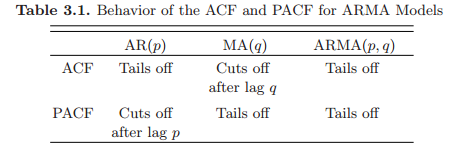

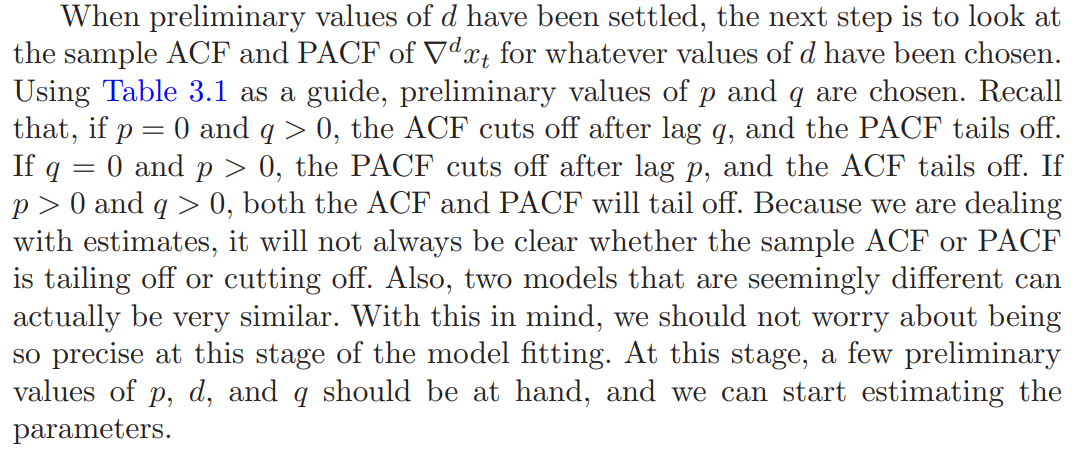

# Ejemplo 1

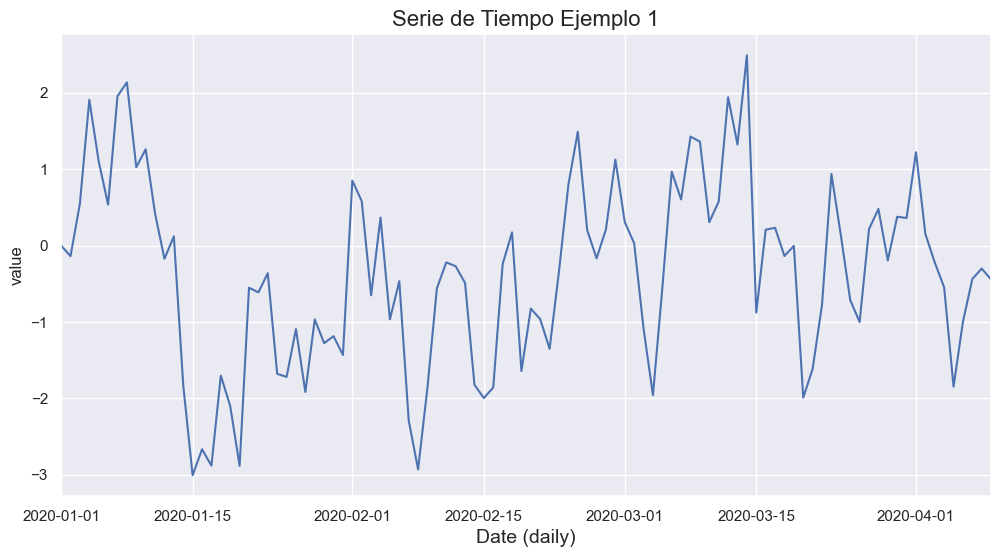

In [6]:
df_1 = pd.read_csv('serie_tiempo_1.csv',
                           index_col='date',
                            parse_dates=True) # parse_dates convierte la columna en formato fecha
# Visualización de la serie de tiempo
plt.figure(figsize=(12,6))
sns.lineplot(data=df_1, x=df_1.index, y='value')
plt.xlim(df_1.index.min(), df_1.index.max())
plt.xlabel('Date (daily)', fontsize=14)
plt.title('Serie de Tiempo Ejemplo 1', fontsize=16)
plt.show()

In [7]:
# Estacionariedad
print("H0: non-stationary\n---------------------------------")

result = adfuller(df_1)
print(f'ADF Statistic:', result[0])
print(f'p-value:', result[1])
print('Number of lags used:', result[2])
if result[1] < 0.05:
    print(f'The series is stationary.')
else:
    print(f'The series is non-stationary.')
print('---')

H0: non-stationary
---------------------------------
ADF Statistic: -4.378481761536808
p-value: 0.00032397103060153464
Number of lags used: 0
The series is stationary.
---


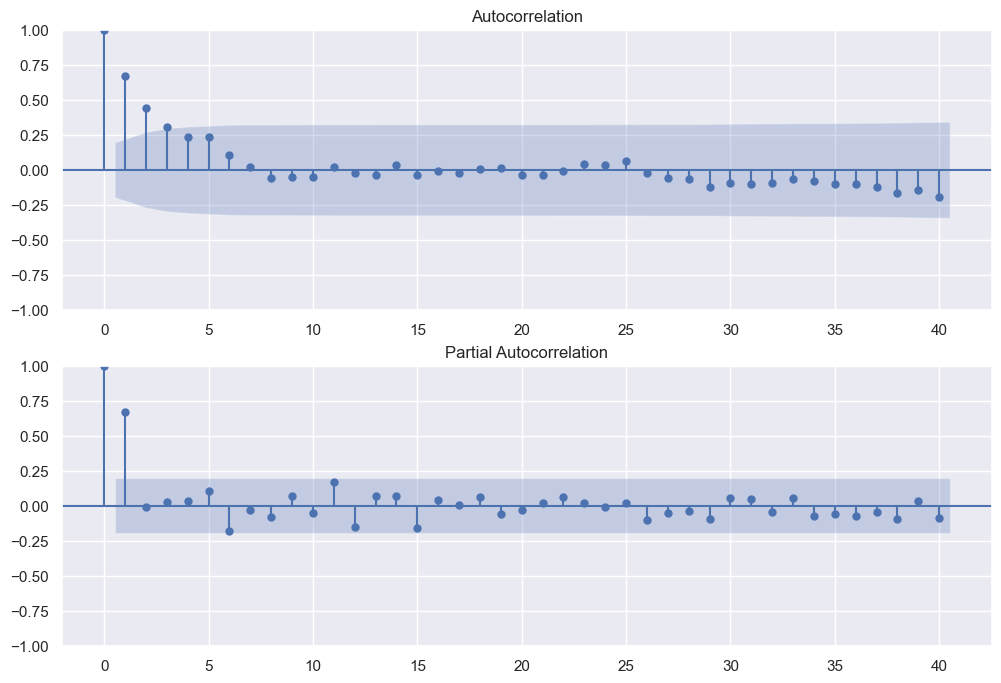

In [8]:
# Autocorrelación y autocorrelación parcial
fig, ax = plt.subplots(2,1, figsize=(12,8))
plot_acf(df_1, ax=ax[0], lags=40)
plot_pacf(df_1, ax=ax[1], lags=40)
plt.show()

La región sombreada de azul es el nivel de confianza al 95%, así que cualquier rezago que se salga de esta banda se interpreta como significativo.

Como pudimos apreciar en las pruebas diagnostico, la serie temporal es efectivamente estacionaria. Además, se ve que el comportamiento de su ACF es decreciente a medida que aumenta el número de rezagos y para el PACF se ve un pico en el rezago 1 y un abruto decaimiento en el resto de los rezagos.

Esto nos lleva a suponer que la serie temporal sigue un AR(1)

In [9]:
# 80% entrenamiento, 20% prueba. Aunque puede variar según el caso
train_size = int(len(df_1) * 0.8)
train, validation = df_1.iloc[:train_size], df_1.iloc[train_size:]
print(f'Train size: {len(train)}')
print(f'Validation size: {len(validation)}')

Train size: 80
Validation size: 20


In [10]:
# ARIMA(1,0,0) = AR(1)
ARIMA_model = ARIMA(train, order=(1,0,0))
ARIMA_result = ARIMA_model.fit()
print(ARIMA_result.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                   80
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -109.686
Date:                Tue, 18 Nov 2025   AIC                            225.373
Time:                        00:25:17   BIC                            232.519
Sample:                    01-01-2020   HQIC                           228.238
                         - 03-20-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4072      0.339     -1.201      0.230      -1.072       0.257
ar.L1          0.6832      0.079      8.685      0.000       0.529       0.837
sigma2         0.9016      0.161      5.589      0.0

c:\Users\ANDRES\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\ANDRES\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\ANDRES\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


### Tabla de ejemplo resaltada (ignoren los resultados de esta tabla)
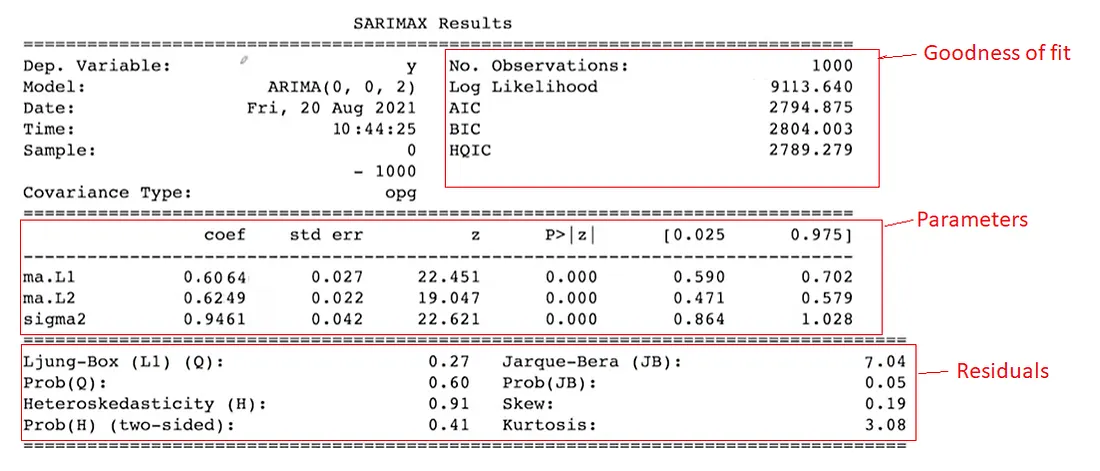

Interpretación del summary del modelo ARIMA

A partir del resumen generado por el modelo, nos enfocamos en dos elementos:

1. los parámetros estimados, y
2. los diagnósticos de los residuos.

El goodness of fit (AIC, BIC, HQIC, Log-Likelihood) indica qué tan bien se ajusta el modelo en términos relativos, pero no entraremos en detalle aquí porque no afecta la interpretación estadística central del modelo.

### 1. Parámetros estimados

En la tabla de coeficientes se presentan:

* coef: valor estimado del parámetro
* std err: su error estándar
* z: estadístico de prueba
* P>|z|: p-value frente a la hipótesis nula
* [0.025, 0.975]: intervalo de confianza al 95%
* La hipótesis nula para todos los parámetros es: $H_0$ : coeficiente = 0

Los resultados muestran
* ar.L1 $(\phi_1)$ → p-value = 0.000: el parámetro es claramente significativo.

* sigma2 $(\sigma^2)$ → p-value = 0.000: la varianza del error es significativamente distinta de cero.

* const (drift) → p-value = 0.230: no rechaza $H_0$. El término constante no es significativo, por lo que se podría eliminar sin afectar el desempeño del modelo.

En resumen, el modelo se sostiene principalmente sobre el componente autorregresivo AR(1); el “drift” no aporta evidencia estadística suficiente para permanecer.

### 2. Diagnóstico de los residuos
La tabla inferior evalúa si los residuos cumplen tres propiedades fundamentales:
no autocorrelación, varianza constante, y normalidad.

#### 2.1. Autocorrelación: Test de Ljung-Box

* $H_0$: los residuos no presentan autocorrelación.

* Resultado: estadístico de prueba (Q) = 0.01, p-value = 0.91.

No se rechaza $H_0$; los residuos se comportan como ruido blanco en términos de autocorrelación.

#### 2.2. Heterocedasticidad: Test de White

* $H_0$: la varianza del error es constante (homocedasticidad).

* Resultado: estadístico de prueba (H) = 1.23, p-value = 0.59.

No se rechaza $H_0$; no hay evidencia de heterocedasticidad.

#### 2.3. Normalidad: Test de Jarque-Bera

¨$H_0$: los residuos siguen una distribución normal.

* Resultado: estadístico de prueba (JB) = 0.71, p-value = 0.70.

No se rechaza $H_0$; los residuos son compatibles con normalidad.

In [11]:
# ARIMA(1,0,0) = AR(1) sin intercepto
ARIMA_model = ARIMA(train, order=(1,0,0),
                    trend='n' # sin intercepto
                    )
ARIMA_result = ARIMA_model.fit()
print(ARIMA_result.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                   80
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -110.405
Date:                Tue, 18 Nov 2025   AIC                            224.809
Time:                        00:25:17   BIC                            229.573
Sample:                    01-01-2020   HQIC                           226.719
                         - 03-20-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7086      0.077      9.180      0.000       0.557       0.860
sigma2         0.9171      0.156      5.884      0.000       0.612       1.223
Ljung-Box (L1) (Q):                   0.11   Jarque-

c:\Users\ANDRES\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\ANDRES\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\ANDRES\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


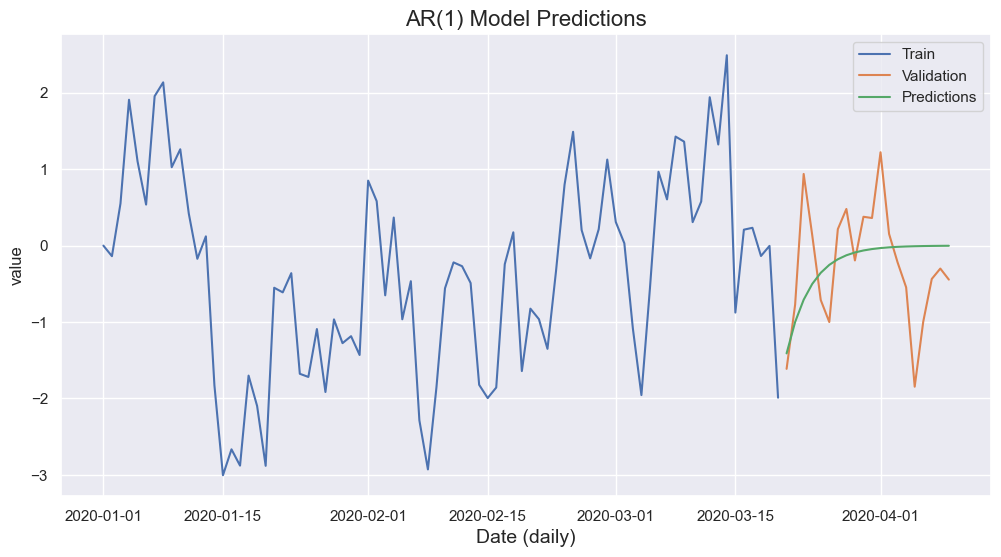

In [12]:
predictions = ARIMA_result.predict(start=len(train), end=len(train)+len(validation)-1)
predictions = pd.DataFrame(predictions)
predictions.columns = ['value']

# Visualización de resultados
plt.figure(figsize=(12,6))
sns.lineplot(data=train, x=train.index, y='value', label='Train')
sns.lineplot(data=validation, x=validation.index, y='value', label='Validation')
sns.lineplot(data=predictions, x=predictions.index, y='value', label='Predictions')
plt.xlabel('Date (daily)', fontsize=14)
plt.title('AR(1) Model Predictions', fontsize=16)
plt.show()

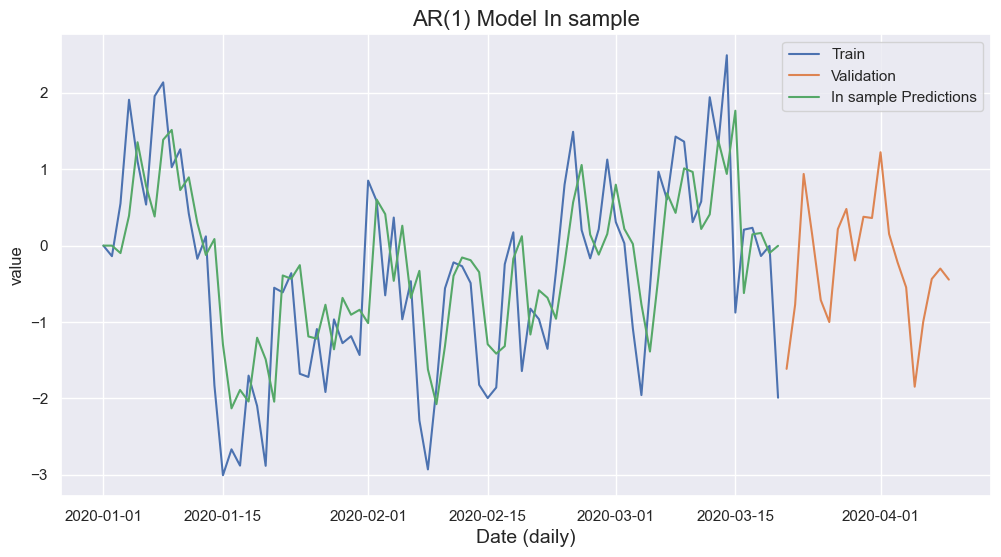

In [13]:
in_sample = ARIMA_result.predict(0)
in_sample = pd.DataFrame(in_sample)
in_sample.columns = ['value']

# Visualización de resultados
plt.figure(figsize=(12,6))
sns.lineplot(data=train, x=train.index, y='value', label='Train')
sns.lineplot(data=validation, x=validation.index, y='value', label='Validation')
sns.lineplot(data=in_sample, x=in_sample.index, y='value', label='In sample Predictions')
plt.xlabel('Date (daily)', fontsize=14)
plt.title('AR(1) Model In sample', fontsize=16)
plt.show()

Nota personal: no entiendo por qué en el conjunto de validación la predicción es tan mala. Aún así vamos a presentar las metricas del modelo.

In [14]:
mae = mean_absolute_error(validation, predictions)
mse = mean_squared_error(validation, predictions)
mape = mean_absolute_percentage_error(validation, predictions)*100
# Presentación de métricas con 2 decimales
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'MAPE: {mape:.2f}%')

MAE: 0.60
MSE: 0.58
MAPE: 115.14%


Valores cercanos a cero indican un buen ajuste. Entre todas las métricas, la más exigente suele ser el MAPE, y en este caso se observa un valor elevado. Aunque las otras dos métricas son las más utilizadas en la literatura, personalmente recomiendo fijarse en el MAPE: un modelo excelente suele tener un MAPE inferior al 5%, algo difícil de lograr.

No se preocupen demasiado por el rendimiento del modelo en esta etapa. Lo importante es comprender la metodología base de las series de tiempo. Aprenderán a lo largo del camino nuevas técnicas y modelos más avanzados. Como adelanto motivador: en un trabajo de procesos estocásticos logré obtener un MAPE de 1.1%.

# Ejercicio 1

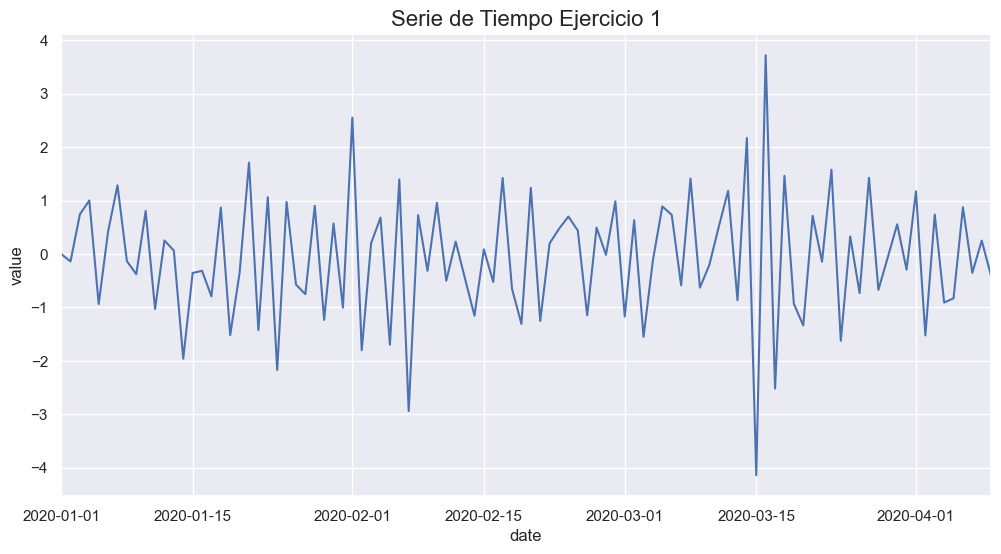

In [15]:
df_2 = pd.read_csv('serie_tiempo_2.csv',
                           index_col='date',
                            parse_dates=True) # parse_dates convierte la columna en formato fecha
# Visualización de la serie de tiempo
plt.figure(figsize=(12,6))
sns.lineplot(data=df_2, x=df_2.index, y='value')
plt.xlim(df_2.index.min(), df_2.index.max())
plt.title('Serie de Tiempo Ejercicio 1', fontsize=16)
plt.show()

#TODO: realizar análisis similar al de la serie 1
* Pruebas diagnosticas
* Partir conjunto de datos
* Selección del modelo
* Revisión de supuestos
* Calcular métricas para el conjunto de validación

# Ejemplo 2

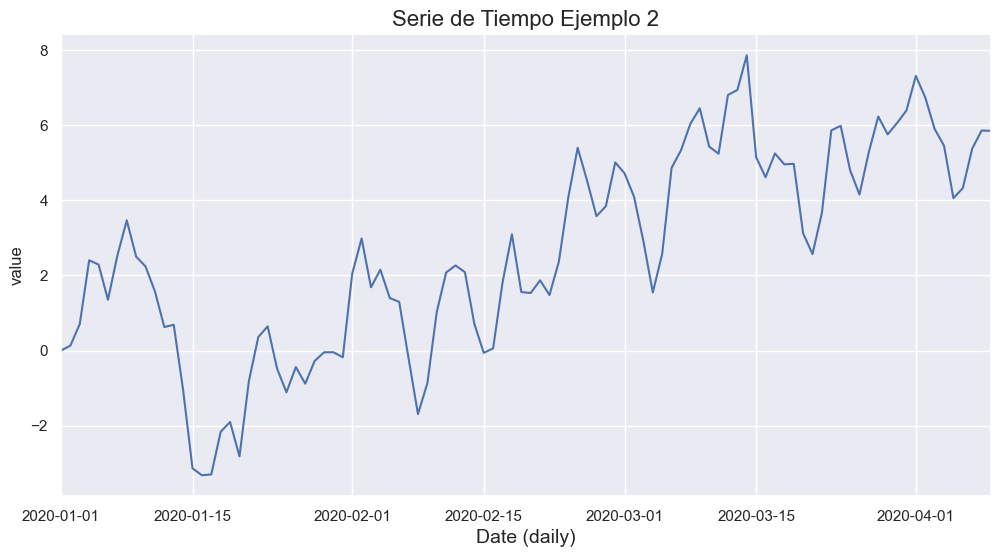

In [16]:
df_3 = pd.read_csv('serie_tiempo_3.csv',
                           index_col='date',
                            parse_dates=True) # parse_dates convierte la columna en formato fecha
# Visualización de la serie de tiempo
plt.figure(figsize=(12,6))
sns.lineplot(data=df_3, x=df_3.index, y='value')
plt.xlim(df_3.index.min(), df_3.index.max())
plt.xlabel('Date (daily)', fontsize=14)
plt.title('Serie de Tiempo Ejemplo 2', fontsize=16)
plt.show()

In [17]:
# Estacionariedad
print("H0: non-stationary\n---------------------------------")

result = adfuller(df_3)
print(f'ADF Statistic:', result[0])
print(f'p-value:', result[1])
print('Number of lags used:', result[2])
if result[1] < 0.05:
    print(f'The series is stationary.')
else:
    print(f'The series is non-stationary.')
print('---')

H0: non-stationary
---------------------------------
ADF Statistic: -1.624216708009712
p-value: 0.47051934051351796
Number of lags used: 2
The series is non-stationary.
---


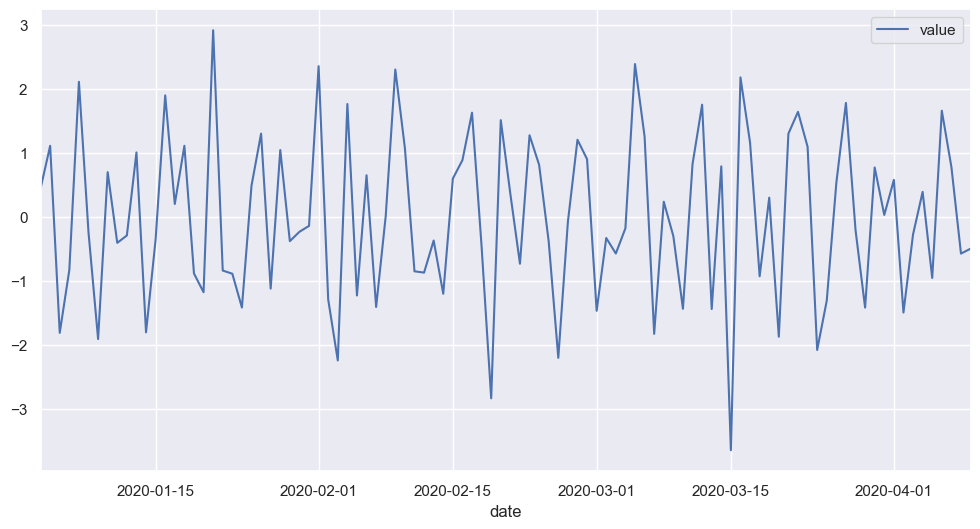

H0: non-stationary
---------------------------------
ADF Statistic: -6.084810082839193
p-value: 1.0707145578340705e-07
Number of lags used: 12
The series is stationary.
---


In [18]:
# Diferenciar la serie para que sea estacionaria
df_3_diff = df_3.diff().dropna().diff().dropna()

plt.figure(figsize=(12,6))
sns.lineplot(data=df_3_diff)
plt.xlim(df_3_diff.index.min(), df_3_diff.index.max())

plt.show()

# Estacionariedad
print("H0: non-stationary\n---------------------------------")
result = adfuller(df_3_diff)
print(f'ADF Statistic:', result[0])
print(f'p-value:', result[1])
print('Number of lags used:', result[2])
if result[1] < 0.05:
    print(f'The series is stationary.')
else:
    print(f'The series is non-stationary.')
print('---')

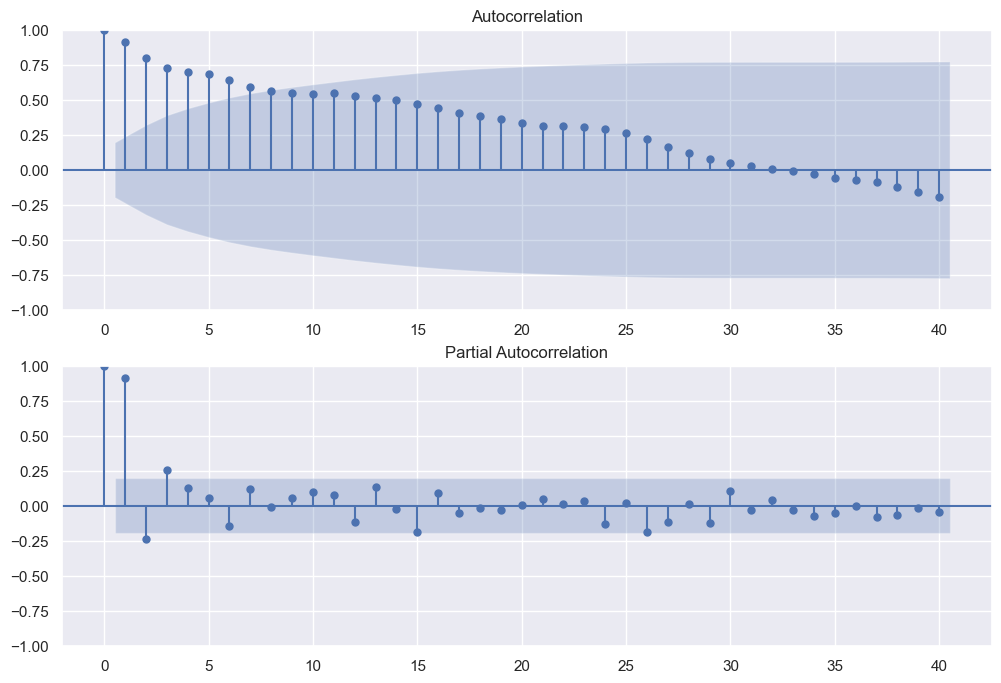

In [19]:
# Autocorrelación y autocorrelación parcial
fig, ax = plt.subplots(2,1, figsize=(12,8))
plot_acf(df_3, ax=ax[0], lags=40)
plot_pacf(df_3, ax=ax[1], lags=40)
plt.show()

Nuevamente se observan patrones similares a los del primer ejemplo: ACF con decaimiento exponencial y PACF que corta después del primer lag, lo que sugiere un componente autorregresivo de orden 1 AR(1). Aunque se pueden observar ligeros picos en los lags 2 y 3 en el PACF, así que se podría considerar un rezago media movil (MA) adicional para capturar mejor la dinámica de la serie temporal.

In [20]:
# 80% entrenamiento, 20% prueba. Aunque puede variar según el caso
train_size = int(len(df_3) * 0.8)
train, validation = df_3.iloc[:train_size], df_3.iloc[train_size:]
print(f'Train size: {len(train)}')
print(f'Validation size: {len(validation)}')

Train size: 80
Validation size: 20


In [21]:
# ARIMA(1,1,1) = AR(1) + MA(1)
ARIMA_model = ARIMA(train, order=(1,1,1),
                    trend='n' # sin intercepto
                    )
ARIMA_result = ARIMA_model.fit()
print(ARIMA_result.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                   80
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -112.294
Date:                Tue, 18 Nov 2025   AIC                            230.588
Time:                        00:25:19   BIC                            237.696
Sample:                    01-01-2020   HQIC                           233.436
                         - 03-20-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5244      0.215     -2.437      0.015      -0.946      -0.103
ma.L1          0.8406      0.139      6.036      0.000       0.568       1.114
sigma2         1.0001      0.157      6.388      0.0

c:\Users\ANDRES\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\ANDRES\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\ANDRES\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Note que tomé la base de datos original sin diferenciar, por eso escogí ARIMA(1,1,1). Aunque también pude haber agarrado la serie ya diferenciada y cambiar el modelo por ARIMA(1,0,1).

En los resultados se observa que los coeficientes del modelo y el $\sigma^2$ estimado son significativos. Similarmente, se comprueba que los residuales no rechaza ninguna de las hipotesis nulas: No autocorrelacion, homocedasticidad y normalidad.

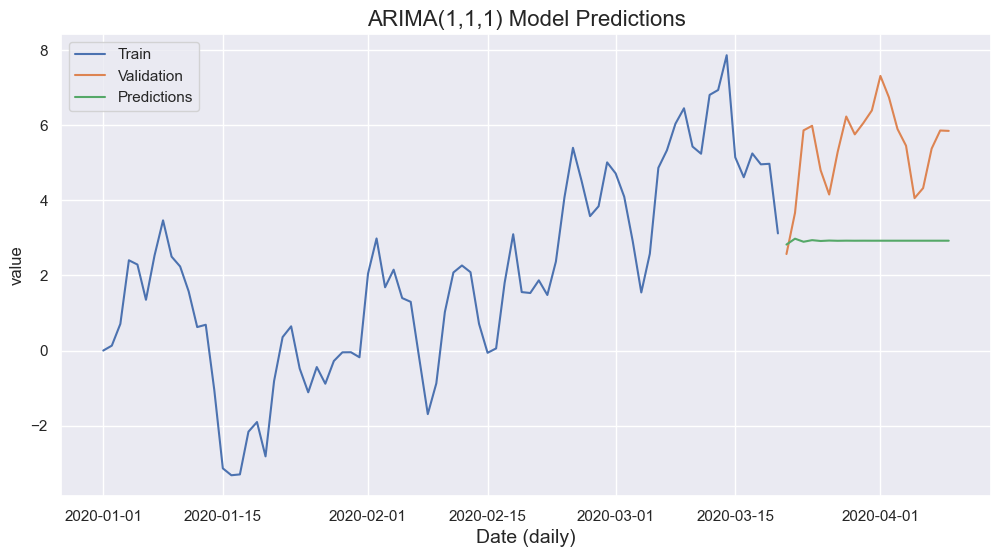

In [22]:
predictions = ARIMA_result.predict(start=len(train), end=len(df_3)-1)
predictions = pd.DataFrame(predictions)
predictions.columns = ['value']

# Visualización de resultados
plt.figure(figsize=(12,6))
sns.lineplot(data=train, x=train.index, y='value', label='Train')
sns.lineplot(data=validation, x=validation.index, y='value', label='Validation')
sns.lineplot(data=predictions, x=predictions.index, y='value', label='Predictions')
plt.xlabel('Date (daily)', fontsize=14)
plt.title('ARIMA(1,1,1) Model Predictions', fontsize=16)
plt.show()

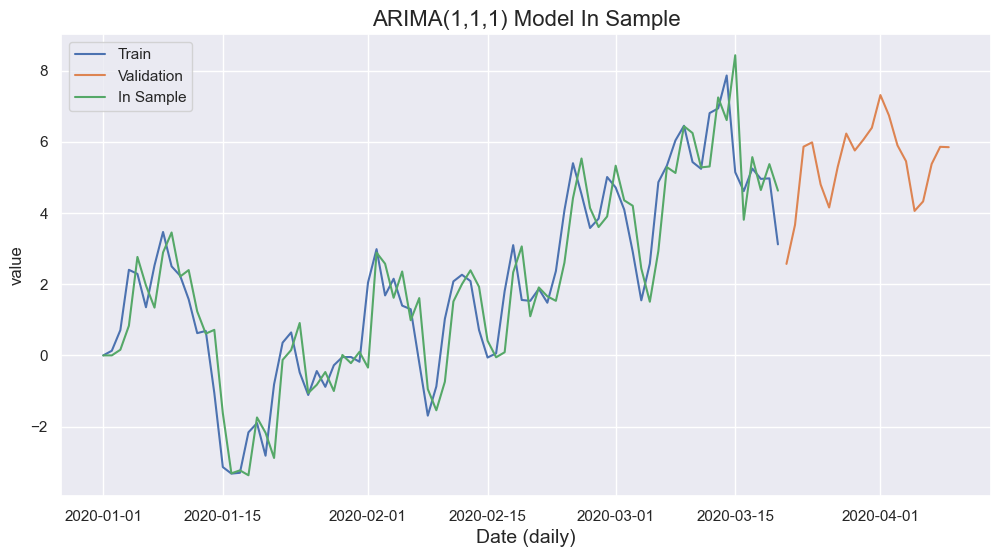

In [23]:
in_sample = ARIMA_result.predict(0)
in_sample = pd.DataFrame(in_sample)
in_sample.columns = ['value']

# Visualización de resultados
plt.figure(figsize=(12,6))
sns.lineplot(data=train, x=train.index, y='value', label='Train')
sns.lineplot(data=validation, x=validation.index, y='value', label='Validation')
sns.lineplot(data=in_sample, x=in_sample.index, y='value', label='In Sample')
plt.xlabel('Date (daily)', fontsize=14)
plt.title('ARIMA(1,1,1) Model In Sample', fontsize=16)
plt.show()

# Ejercicio 2

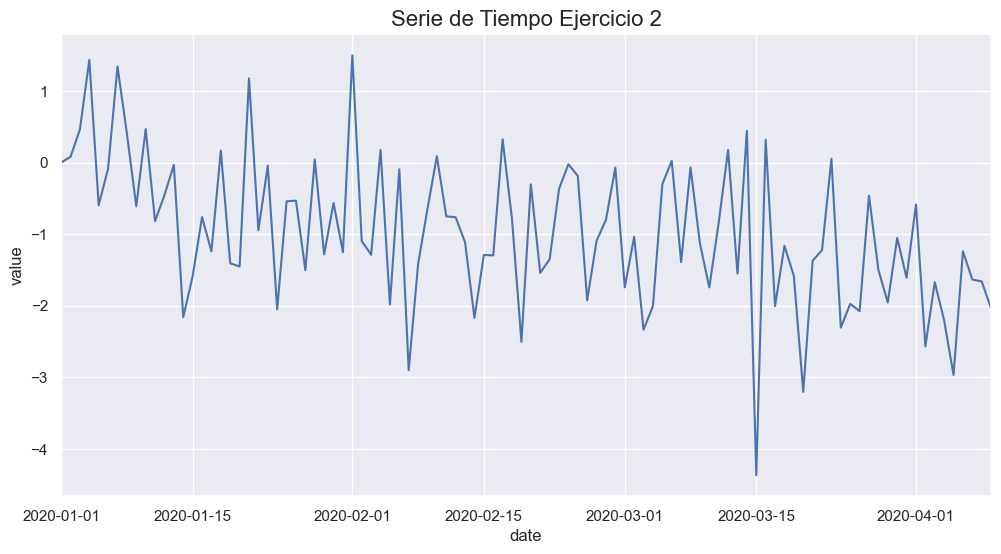

In [25]:
df_4 = pd.read_csv('serie_tiempo_4.csv',
                           index_col='date',
                            parse_dates=True) # parse_dates convierte la columna en formato fecha
# Visualización de la serie de tiempo
plt.figure(figsize=(12,6))
sns.lineplot(data=df_4, x=df_4.index, y='value')
plt.xlim(df_4.index.min(), df_4.index.max())
plt.title('Serie de Tiempo Ejercicio 2', fontsize=16)
plt.show()

#TODO: realizar análisis similar al de la serie 3
* Pruebas diagnosticas
* Usar diferencias si es necesario
* Partir conjunto de datos
* Selección del modelo
* Revisión de supuestos
* Calcular métricas para el conjunto de validación